# ME-XBAL (Multilingual Emotion eXplainable BALancer)

In [4]:
# ==========================================
# 🔬 TOKOPEDIA EMOTION DATASET (SINGLE LABEL)
# ==========================================
import pandas as pd
import numpy as np
import torch
import joblib
import xgboost as xgb
from sklearn.metrics import f1_score, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# ==========================================
# 1. LOAD DATASET
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/jocelyndumlao/prdect-id-indonesian-emotion-classification/Product Reviews Dataset for Emotions Classification Tasks - Indonesian (PRDECT-ID) Dataset/PRDECT-ID Dataset.csv')

print("Columns:", df.columns)
print(df.head())

# Sesuaikan nama kolom
text_col = "Customer Review"
label_col = "Emotion"

# Drop missing
df = df[[text_col, label_col]].dropna()

# ==========================================
# 2. LABEL ENCODING
# ==========================================
le = LabelEncoder()
df['label'] = le.fit_transform(df[label_col])

print("\nClasses:", le.classes_)

# ==========================================
# 3. TRAIN TEST SPLIT
# ==========================================
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

y_train = df_train['label'].values
y_test  = df_test['label'].values

# ==========================================
# 4. LOAD XLM-R
# ==========================================
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

# ==========================================
# 5. EMBEDDING FUNCTION (MASKED MEAN POOLING)
# Mean pooling ter-mask dipakai sebagai representasi kalimat,
# karena token CLS pada XLM-R tidak dilatih dengan objective
# tingkat kalimat sehingga lemah tanpa fine-tuning
# ==========================================
def extract_embeddings(texts, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            last = outputs.last_hidden_state
            mask = inputs['attention_mask'].unsqueeze(-1).float()
            emb = (last * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
            embeddings.append(emb.cpu().numpy())

    return np.vstack(embeddings)

# ==========================================
# 6. FEATURE EXTRACTION
# ==========================================
print("\n🔄 Extracting embeddings...")
X_train = extract_embeddings(df_train[text_col].astype(str).tolist())
X_test  = extract_embeddings(df_test[text_col].astype(str).tolist())

# ==========================================
# 7. PREPROCESSING
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("\nReduced dim:", X_train_pca.shape[1])

# ==========================================
# 8. TRAIN MODELS (ME-XBAL)
# - Cost-sensitive XGBoost: sample_weight 'balanced'
# - LR: class_weight='balanced', C=0.1
# ==========================================
num_classes = len(le.classes_)

XGB_PARAMS = {
    'objective': 'multi:softprob',
    'max_depth': 3,
    'min_child_weight': 5,
    'learning_rate': 0.05,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.5,
    'eval_metric': 'mlogloss',
    'random_state': 42,
    'verbosity': 0,
    'n_jobs': -1
}

def train_xgb_balanced(X, y):
    m = xgb.XGBClassifier(num_class=num_classes, **XGB_PARAMS)
    m.fit(X, y, sample_weight=compute_sample_weight('balanced', y))
    return m

def train_lr_balanced(X, y):
    m = LogisticRegression(
        C=0.1,
        max_iter=1000,
        random_state=42,
        solver='lbfgs',
        class_weight='balanced'
    )
    m.fit(X, y)
    return m

xgb_model = train_xgb_balanced(X_train_pca, y_train)
lr_model  = train_lr_balanced(X_train_pca, y_train)

# ==========================================
# 9. ADAPTIVE ENSEMBLE WEIGHT (5-FOLD CV DI TRAIN)
# Bobot ensemble dipilih dari out-of-fold prediction
# pada data TRAIN saja — test set TIDAK disentuh
# ==========================================
def oof_probas(X, y, train_fn, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof = np.zeros((len(y), num_classes))
    for tr_idx, va_idx in skf.split(X, y):
        m = train_fn(X[tr_idx], y[tr_idx])
        oof[va_idx] = m.predict_proba(X[va_idx])
    return oof

print("\n🔄 Mencari bobot ensemble adaptif (5-fold CV di train)...")
oof_xgb = oof_probas(X_train_pca, y_train, train_xgb_balanced)
oof_lr  = oof_probas(X_train_pca, y_train, train_lr_balanced)

W_XGB, best_cv = 0.5, -1.0
for w in np.arange(0.0, 1.0001, 0.05):
    f1_cv = f1_score(
        y_train,
        np.argmax(w * oof_xgb + (1 - w) * oof_lr, axis=1),
        average='macro'
    )
    if f1_cv > best_cv:
        best_cv, W_XGB = f1_cv, w

print(f"Bobot adaptif: w_xgb={W_XGB:.2f}, w_lr={1-W_XGB:.2f} (CV macro-F1={best_cv:.4f})")

# ==========================================
# 10. PREDICTION (HYBRID)
# ==========================================
xgb_proba = xgb_model.predict_proba(X_test_pca)
lr_proba  = lr_model.predict_proba(X_test_pca)

hybrid_proba = W_XGB * xgb_proba + (1 - W_XGB) * lr_proba
y_pred = np.argmax(hybrid_proba, axis=1)

# ==========================================
# 11. EVALUATION
# ==========================================
macro_f1 = f1_score(y_test, y_pred, average='macro')
micro_f1 = f1_score(y_test, y_pred, average='micro')
acc = accuracy_score(y_test, y_pred)

print("\n📊 RESULTS (TOKOPEDIA DATASET - SINGLE LABEL)")
print("="*60)
print(f"Macro F1 : {macro_f1:.4f}")
print(f"Micro F1 : {micro_f1:.4f}")
print(f"Accuracy : {acc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=np.arange(len(le.classes_)),
    target_names=le.classes_,
    zero_division=0
))

Columns: Index(['Category', 'Product Name', 'Location', 'Price', 'Overall Rating',
       'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review',
       'Sentiment', 'Emotion'],
      dtype='object')
                Category                                       Product Name  \
0  Computers and Laptops  Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...   
1  Computers and Laptops  PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...   
2  Computers and Laptops                SSD Midasforce 128 Gb - Tanpa Caddy   
3  Computers and Laptops  ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...   
4  Computers and Laptops  ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...   

                 Location   Price  Overall Rating  Number Sold  Total Review  \
0           Jakarta Utara   53500             4.9         5449          2369   
1  Kota Tangerang Selatan   72000             4.9         2359          1044   
2           Jakarta Barat  213000             5.0        12300          

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🔄 Extracting embeddings...


100%|██████████| 34/34 [00:04<00:00,  7.03it/s]



Reduced dim: 288

🔄 Mencari bobot ensemble adaptif (5-fold CV di train)...
Bobot adaptif: w_xgb=0.65, w_lr=0.35 (CV macro-F1=0.6087)

📊 RESULTS (TOKOPEDIA DATASET - SINGLE LABEL)
Macro F1 : 0.5821
Micro F1 : 0.6111
Accuracy : 0.6111

📋 Classification Report:
              precision    recall  f1-score   support

       Anger       0.43      0.48      0.45       140
        Fear       0.49      0.50      0.50       184
       Happy       0.82      0.73      0.77       354
        Love       0.59      0.69      0.64       162
     Sadness       0.56      0.54      0.55       240

    accuracy                           0.61      1080
   macro avg       0.58      0.59      0.58      1080
weighted avg       0.62      0.61      0.61      1080



# Confusion Matrix per Emotion

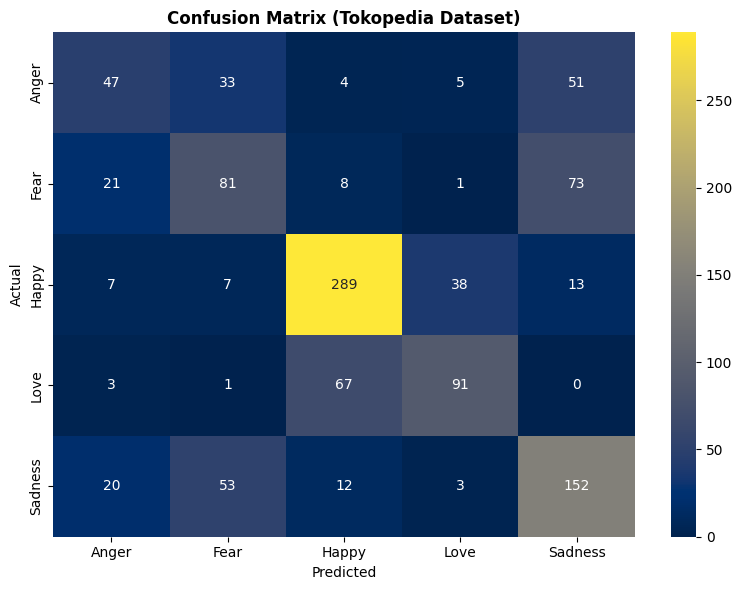

In [9]:
# ==========================================
# 📊 CONFUSION MATRIX (TOKOPEDIA)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ================================
# 1. CONFUSION MATRIX (MULTI-CLASS)
# ================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='cividis',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Tokopedia Dataset)", fontweight='bold')
plt.tight_layout()
plt.show()

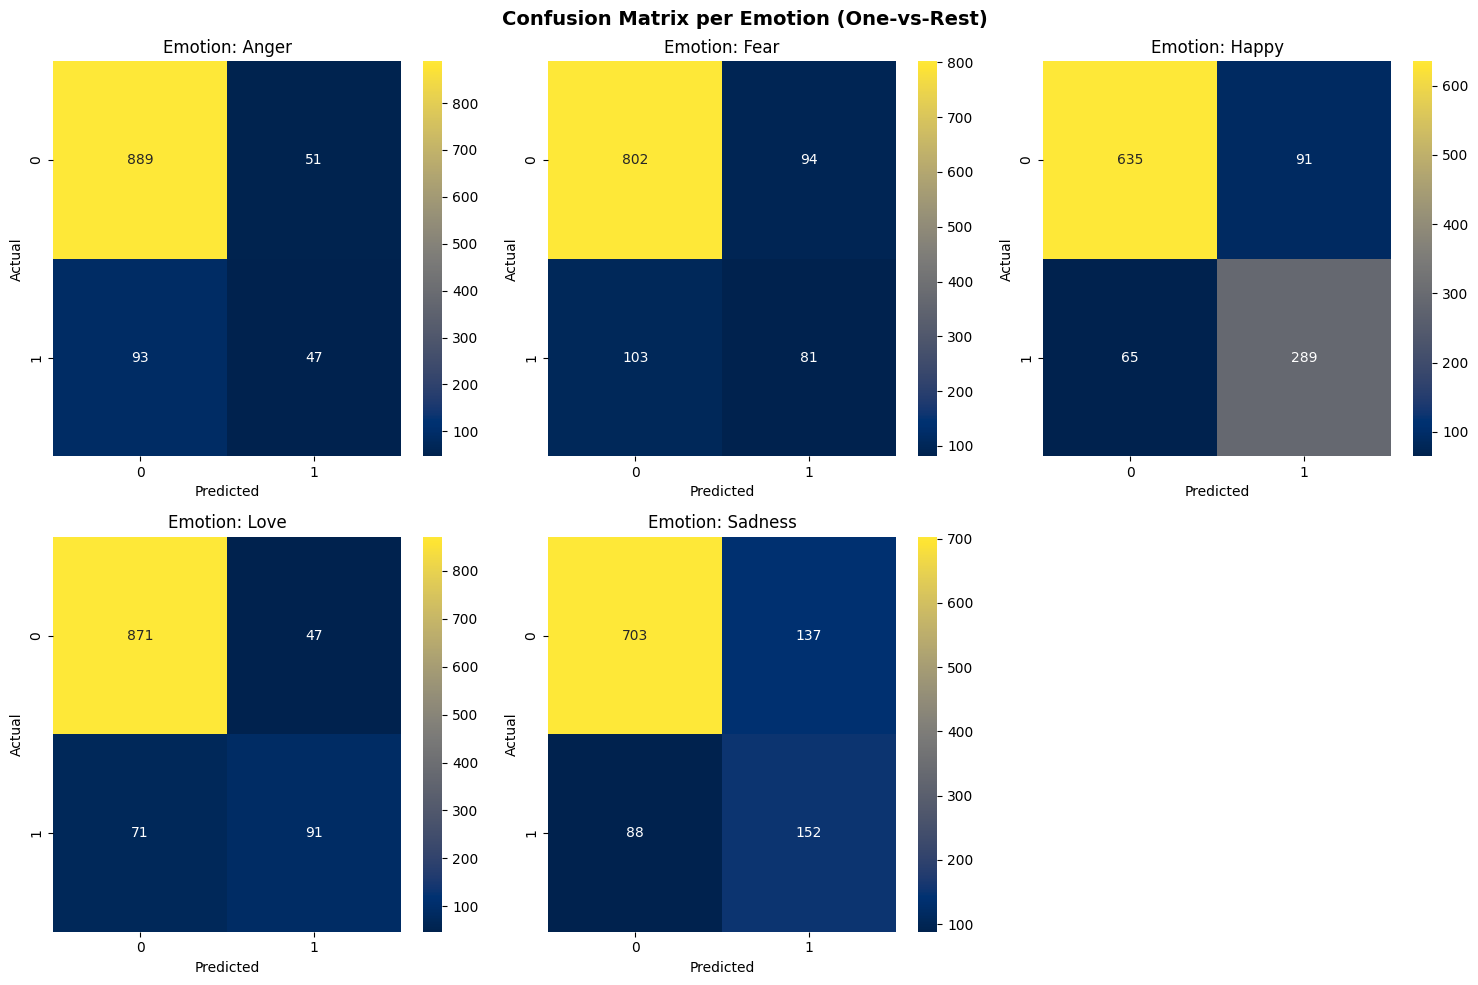

In [10]:
# ==========================================
# 📊 CONFUSION MATRIX PER EMOTION
# ==========================================
num_classes = len(le.classes_)

fig, axes = plt.subplots(
    int(np.ceil(num_classes / 3)),
    3,
    figsize=(15, 5 * int(np.ceil(num_classes / 3)))
)

axes = axes.flatten()

for i in range(num_classes):

    # ubah ke binary (one-vs-rest)
    y_true_bin = (y_test == i).astype(int)
    y_pred_bin = (y_pred == i).astype(int)

    cm = confusion_matrix(y_true_bin, y_pred_bin)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='cividis',
        ax=axes[i]
    )

    axes[i].set_title(f"Emotion: {le.classes_[i]}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# hapus subplot kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Confusion Matrix per Emotion (One-vs-Rest)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

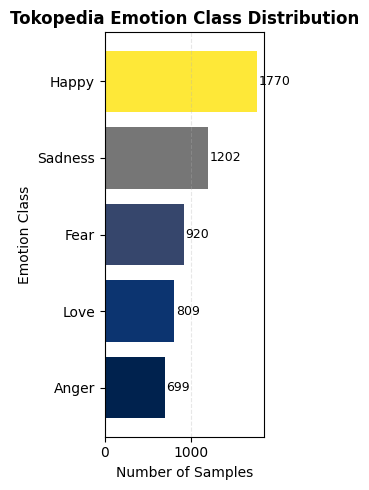

In [11]:
# ==========================================
# 📊 TOKOPEDIA CLASS DISTRIBUTION
# (HORIZONTAL BAR CHART)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# ================================
# COUNT LABELS
# ================================
class_counts = df[label_col].value_counts()

labels = class_counts.index.tolist()
values = class_counts.values.tolist()

# ================================
# SORT (OPTIONAL)
# ================================
sorted_idx = np.argsort(values)

labels = [labels[i] for i in sorted_idx]
values = [values[i] for i in sorted_idx]

# ================================
# CIVIDIS COLORS
# ================================
cmap = plt.cm.cividis

norm = (
    (np.array(values) - np.min(values))
    / (np.max(values) - np.min(values))
)

colors = [cmap(n) for n in norm]

# ================================
# PLOT
# ================================
plt.figure(figsize=(3,5))

bars = plt.barh(
    labels,
    values,
    color=colors
)

# ================================
# VALUE LABELS
# ================================
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 20,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va='center',
        fontsize=9
    )

# ================================
# LABELS & TITLE
# ================================
plt.xlabel("Number of Samples")
plt.ylabel("Emotion Class")

plt.title(
    "Tokopedia Emotion Class Distribution",
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Explainability Using SHAP

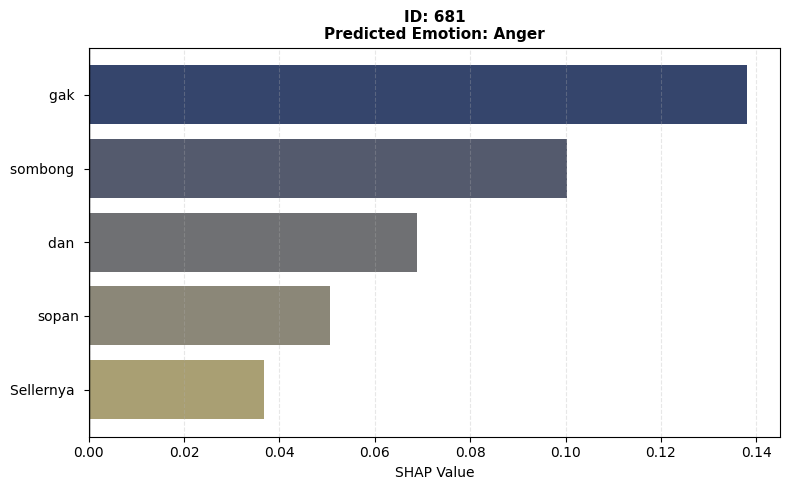

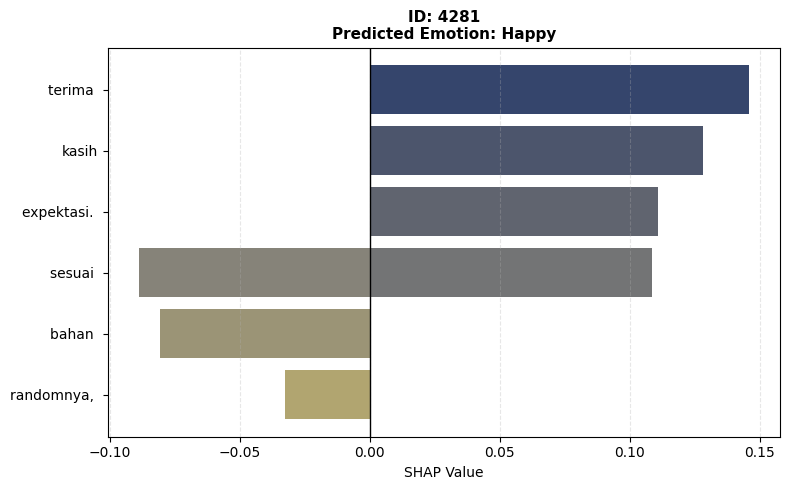

  0%|          | 0/498 [00:00<?, ?it/s]

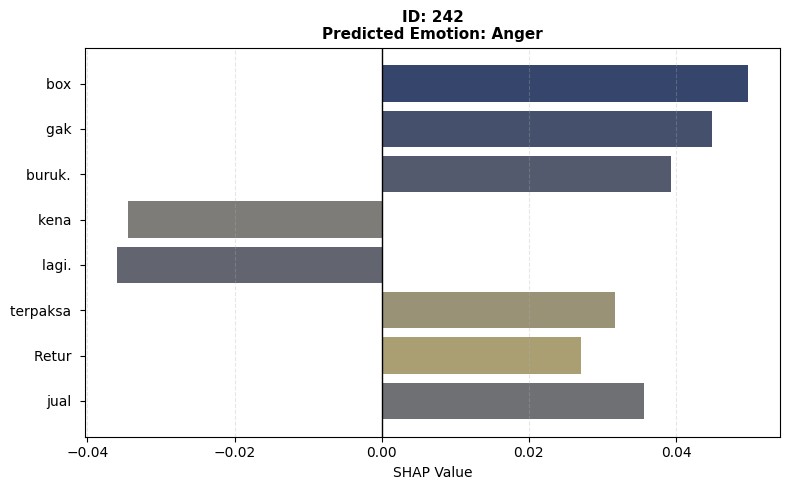

In [12]:
# ==========================================
# 🔍 SHAP EXPLAINABILITY (TOKOPEDIA - SINGLE LABEL)
# ==========================================
import shap
import numpy as np
import matplotlib.pyplot as plt

shap.initjs()

# ================================
# AMBIL SAMPLE DARI TEST SET
# ================================
samples = [
    ("Indonesia", df_test.iloc[0]),
    ("Indonesia", df_test.iloc[1]),
    ("Indonesia", df_test.iloc[2])
]

# ================================
# MASKER (WORD-LEVEL)
# ================================
masker = shap.maskers.Text(r"\W+")

# ================================
# FUNCTION: PREDICT PROBA (MULTI-CLASS)
# ================================
def predict_proba_texts(texts):

    embeddings = []

    for text in texts:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_emb[0])

    X = np.vstack(embeddings)

    X_scaled = scaler.transform(X)
    X_pca = pca.transform(X_scaled)

    # gunakan hybrid (ME-XBAL style)
    xgb_proba = xgb_model.predict_proba(X_pca)
    lr_proba  = lr_model.predict_proba(X_pca)

    hybrid_proba = 0.7 * xgb_proba + 0.3 * lr_proba

    return hybrid_proba


# ================================
# LOOP SHAP
# ================================
for lang, row in samples:

    text = str(row[text_col])
    text_id = row.name  # index sebagai ID

    # ================================
    # PREDICTION
    # ================================
    probs = predict_proba_texts([text])[0]
    pred_idx = np.argmax(probs)
    pred_label = le.classes_[pred_idx]

    # ================================
    # SHAP (FOCUS KE 1 CLASS)
    # ================================
    explainer = shap.Explainer(
        lambda x: predict_proba_texts(x)[:, pred_idx],
        masker
    )

    shap_values = explainer([text])[0]

    words = shap_values.data
    scores = shap_values.values

    # ================================
    # CLEAN TOKEN
    # ================================
    words_clean = []
    scores_clean = []

    for w, s in zip(words, scores):
        if w.strip() != "":
            words_clean.append(w)
            scores_clean.append(s)

    # ================================
    # TOP WORDS
    # ================================
    idx_sorted = np.argsort(np.abs(scores_clean))[::-1][:10]

    words_plot = [words_clean[i] for i in idx_sorted]
    scores_plot = [scores_clean[i] for i in idx_sorted]

    # ================================
    # CIVIDIS COLORS
    # ================================
    cmap = plt.cm.cividis
    colors = [cmap(0.2 + 0.6*(i/len(words_plot))) for i in range(len(words_plot))]

    # ================================
    # PLOT
    # ================================
    plt.figure(figsize=(8, 5))

    plt.barh(words_plot[::-1], scores_plot[::-1], color=colors[::-1])
    plt.axvline(0, color='black', linewidth=1)

    plt.xlabel("SHAP Value")
    plt.title(
        f"ID: {text_id}\nPredicted Emotion: {pred_label}",
        fontsize=11,
        fontweight='bold'
    )

    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Ablation Study

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

🔄 Extracting embeddings...


100%|██████████| 34/34 [00:06<00:00,  5.51it/s]


🔄 Mencari bobot ensemble adaptif ME-XBAL (5-fold CV di train)...
Bobot adaptif ME-XBAL: w_xgb=0.65, w_lr=0.35 (CV macro-F1=0.6087)

📊 RESULTS (TOKOPEDIA - ABLATION)
ME-XBAL             : 0.5821
XLM-R LR            : 0.5584
XLM-R XGB           : 0.5292
XLM-R Hybrid        : 0.5691
IndoBERT LR         : 0.5545
IndoBERT XGB        : 0.5373
IndoBERT Hybrid     : 0.5630


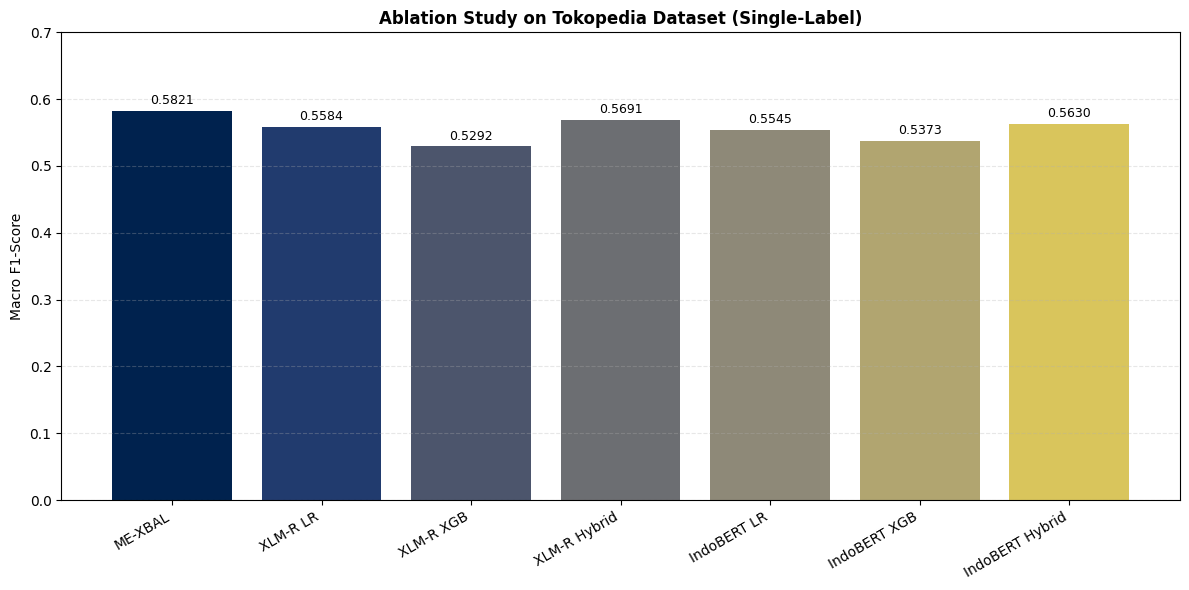

In [5]:
# ==========================================
# 🔬 ABLATION STUDY - TOKOPEDIA DATASET
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm

# ================================
# LOAD TRANSFORMERS
# ================================
def load_model(name):
    tok = AutoTokenizer.from_pretrained(name)
    mod = AutoModel.from_pretrained(name)
    return tok, mod

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

xlmr_tok, xlmr_mod = load_model("xlm-roberta-base")
indo_tok, indo_mod = load_model("indobenchmark/indobert-base-p1")

xlmr_mod.to(device).eval()
indo_mod.to(device).eval()

# ================================
# EMBEDDING FUNCTION (MASKED MEAN POOLING)
# Diterapkan SERAGAM ke semua model (XLM-R & IndoBERT)
# agar perbandingan tetap fair
# ================================
def extract(texts, tokenizer, model):
    out = []
    for i in tqdm(range(0, len(texts), 32)):
        batch = texts[i:i+32]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            last = outputs.last_hidden_state
            mask = inputs['attention_mask'].unsqueeze(-1).float()
            emb = (last * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
            out.append(emb.cpu().numpy())

    return np.vstack(out)

# ================================
# EXTRACT FEATURES
# ================================
print("🔄 Extracting embeddings...")

X_xlmr_train_raw = extract(df_train[text_col].astype(str).tolist(), xlmr_tok, xlmr_mod)
X_xlmr_test_raw  = extract(df_test[text_col].astype(str).tolist(), xlmr_tok, xlmr_mod)

X_indo_train_raw = extract(df_train[text_col].astype(str).tolist(), indo_tok, indo_mod)
X_indo_test_raw  = extract(df_test[text_col].astype(str).tolist(), indo_tok, indo_mod)

# ================================
# PREPROCESSING
# Scaler & PCA di-fit TERPISAH per jenis embedding (train only),
# agar baseline IndoBERT tidak memakai proyeksi PCA milik XLM-R
# ================================
def fit_preprocess(X_tr_raw, X_te_raw):
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr_raw)
    X_te = sc.transform(X_te_raw)

    p = PCA(n_components=0.95, random_state=42)
    X_tr = p.fit_transform(X_tr)
    X_te = p.transform(X_te)
    return X_tr, X_te

X_xlmr_train, X_xlmr_test = fit_preprocess(X_xlmr_train_raw, X_xlmr_test_raw)
X_indo_train, X_indo_test = fit_preprocess(X_indo_train_raw, X_indo_test_raw)

# ================================
# TRAIN FUNCTIONS - BASELINE (tanpa balancing)
# ================================
def train_xgb(X, y):
    model = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(np.unique(y)),
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42
    )
    model.fit(X, y)
    return model

def train_lr(X, y):
    model = LogisticRegression(max_iter=2000)
    model.fit(X, y)
    return model

# ================================
# TRAIN FUNCTIONS - ME-XBAL
# Konfigurasi mengikuti "semeval-dataset 9 July.ipynb",
# diadaptasi dari multi-label ke single-label multi-class:
# - Cost-sensitive XGBoost: sample_weight 'balanced'
#   (pengganti scale_pos_weight yang hanya berlaku untuk binary)
# - LR: class_weight='balanced', C=0.1 (regularisasi L2 default)
# - Ensemble berbobot ADAPTIF: bobot dipilih via 5-fold CV
#   pada data TRAIN saja (test set tidak disentuh)
# (Threshold optimization per kelas tidak dipakai di sini karena
#  prediksi single-label memakai argmax, bukan threshold biner)
# ================================
XGB_PARAMS_MEXBAL = {
    'objective': 'multi:softprob',
    'max_depth': 3,
    'min_child_weight': 5,
    'learning_rate': 0.05,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.5,
    'eval_metric': 'mlogloss',
    'random_state': 42,
    'verbosity': 0,
    'n_jobs': -1
}

def train_xgb_balanced(X, y):
    model = xgb.XGBClassifier(
        num_class=len(np.unique(y)),
        **XGB_PARAMS_MEXBAL
    )
    model.fit(X, y, sample_weight=compute_sample_weight('balanced', y))
    return model

def train_lr_balanced(X, y):
    model = LogisticRegression(
        C=0.1,
        max_iter=1000,
        random_state=42,
        solver='lbfgs',
        class_weight='balanced'
    )
    model.fit(X, y)
    return model

# ================================
# PREDICT FUNCTION
# ================================
def predict(xgb_m=None, lr_m=None, X=None, w_xgb=0.5, w_lr=0.5):
    if xgb_m is not None and lr_m is not None:
        proba = w_xgb * xgb_m.predict_proba(X) + w_lr * lr_m.predict_proba(X)
    elif xgb_m is not None:
        proba = xgb_m.predict_proba(X)
    else:
        proba = lr_m.predict_proba(X)

    return np.argmax(proba, axis=1)

# ================================
# ADAPTIVE ENSEMBLE WEIGHT (ME-XBAL)
# Out-of-fold prediction 5-fold CV di TRAIN set
# ================================
def oof_probas(X, y, train_fn, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof = np.zeros((len(y), len(np.unique(y))))
    for tr_idx, va_idx in skf.split(X, y):
        m = train_fn(X[tr_idx], y[tr_idx])
        oof[va_idx] = m.predict_proba(X[va_idx])
    return oof

print("🔄 Mencari bobot ensemble adaptif ME-XBAL (5-fold CV di train)...")
oof_xgb = oof_probas(X_xlmr_train, y_train, train_xgb_balanced)
oof_lr  = oof_probas(X_xlmr_train, y_train, train_lr_balanced)

w_me, best_cv = 0.5, -1.0
for w in np.arange(0.0, 1.0001, 0.05):
    f1_cv = f1_score(
        y_train,
        np.argmax(w * oof_xgb + (1 - w) * oof_lr, axis=1),
        average='macro'
    )
    if f1_cv > best_cv:
        best_cv, w_me = f1_cv, w

print(f"Bobot adaptif ME-XBAL: w_xgb={w_me:.2f}, w_lr={1-w_me:.2f} (CV macro-F1={best_cv:.4f})")

# ================================
# TRAIN MODELS (BASELINE)
# ================================
models = {}

# XLM-R
models["XLM-R LR"] = (None, train_lr(X_xlmr_train, y_train))
models["XLM-R XGB"] = (train_xgb(X_xlmr_train, y_train), None)
models["XLM-R Hybrid"] = (
    train_xgb(X_xlmr_train, y_train),
    train_lr(X_xlmr_train, y_train)
)

# IndoBERT
models["IndoBERT LR"] = (None, train_lr(X_indo_train, y_train))
models["IndoBERT XGB"] = (train_xgb(X_indo_train, y_train), None)
models["IndoBERT Hybrid"] = (
    train_xgb(X_indo_train, y_train),
    train_lr(X_indo_train, y_train)
)

# ================================
# EVALUATION
# ================================
results = {}

# ME-XBAL: balanced XGB + balanced LR + ensemble berbobot adaptif
xgb_me = train_xgb_balanced(X_xlmr_train, y_train)
lr_me  = train_lr_balanced(X_xlmr_train, y_train)
y_pred_me = predict(xgb_me, lr_me, X_xlmr_test, w_xgb=w_me, w_lr=1-w_me)
results["ME-XBAL"] = f1_score(y_test, y_pred_me, average='macro')

# Baseline: hybrid = rata-rata 50/50, single model = proba langsung
for name, (xgb_m, lr_m) in models.items():
    X_used = X_xlmr_test if "XLM-R" in name else X_indo_test
    y_pred = predict(xgb_m, lr_m, X_used)

    results[name] = f1_score(y_test, y_pred, average='macro')

# ================================
# PRINT RESULTS
# ================================
print("\n📊 RESULTS (TOKOPEDIA - ABLATION)")
print("="*50)
for k, v in results.items():
    print(f"{k:<20}: {v:.4f}")

# ================================
# VISUALIZATION (CIVIDIS)
# ================================
models_names = list(results.keys())
scores = list(results.values())

x = np.arange(len(models_names))

plt.figure(figsize=(12,6))

cmap = plt.cm.cividis
colors = [cmap(i/len(models_names)) for i in range(len(models_names))]

bars = plt.bar(x, scores, color=colors)

plt.ylabel("Macro F1-Score")
plt.title("Ablation Study on Tokopedia Dataset (Single-Label)", fontweight='bold')
plt.xticks(x, models_names, rotation=30, ha='right')

# label angka
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.4f}",
             ha='center', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, 0.7)

plt.tight_layout()
plt.show()

# Training Time Vs Inference Time Each Model

In [14]:
# ==========================================
# ⏱️ TIME ANALYSIS (TOKOPEDIA - FULL ABLATION)
# ==========================================
import time
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

results_time = []

# ================================
# FUNCTION: MEASURE TIME
# ================================
def measure_time(name, X_train, y_train, X_test):

    # bobot ensemble default (hybrid baseline = rata-rata 50/50)
    w_xgb_used, w_lr_used = 0.5, 0.5

    # ================================
    # TRAINING
    # ================================
    start_train = time.time()

    if name == "XLM-R LR":
        xgb_m = None
        lr_m = train_lr(X_train, y_train)

    elif name == "XLM-R XGB":
        xgb_m = train_xgb(X_train, y_train)
        lr_m = None

    elif name == "XLM-R Hybrid":
        xgb_m = train_xgb(X_train, y_train)
        lr_m = train_lr(X_train, y_train)

    elif name == "IndoBERT LR":
        xgb_m = None
        lr_m = train_lr(X_train, y_train)

    elif name == "IndoBERT XGB":
        xgb_m = train_xgb(X_train, y_train)
        lr_m = None

    elif name == "IndoBERT Hybrid":
        xgb_m = train_xgb(X_train, y_train)
        lr_m = train_lr(X_train, y_train)

    elif name == "ME-XBAL":
        # Training penuh ME-XBAL: balanced models +
        # pemilihan bobot adaptif (5-fold CV di train)
        oof_xgb = oof_probas(X_train, y_train, train_xgb_balanced)
        oof_lr  = oof_probas(X_train, y_train, train_lr_balanced)

        best_cv = -1.0
        for w in np.arange(0.0, 1.0001, 0.05):
            f1_cv = f1_score(
                y_train,
                np.argmax(w * oof_xgb + (1 - w) * oof_lr, axis=1),
                average='macro'
            )
            if f1_cv > best_cv:
                best_cv, w_xgb_used = f1_cv, w
        w_lr_used = 1 - w_xgb_used

        xgb_m = train_xgb_balanced(X_train, y_train)
        lr_m  = train_lr_balanced(X_train, y_train)

    train_time = time.time() - start_train

    # ================================
    # INFERENCE (AVERAGE)
    # ================================
    runs = 5
    times = []

    for _ in range(runs):
        start_inf = time.time()

        _ = predict(
            xgb_m,
            lr_m,
            X_test,
            w_xgb=w_xgb_used,
            w_lr=w_lr_used
        )

        times.append(time.time() - start_inf)

    inference_time = np.mean(times)

    return train_time, inference_time


# ================================
# MODEL ORDER (PENTING!)
# ================================
model_names = [
    "ME-XBAL",
    "XLM-R Hybrid",
    "XLM-R LR",
    "XLM-R XGB",
    "IndoBERT LR",
    "IndoBERT XGB",
    "IndoBERT Hybrid"
]

# ================================
# LOOP
# ================================
for name in model_names:

    print(f"⏳ Processing {name}...")

    # pilih embedding sesuai model
    if "IndoBERT" in name:
        X_train_used = X_indo_train
        X_test_used  = X_indo_test
    else:
        X_train_used = X_xlmr_train
        X_test_used  = X_xlmr_test

    train_t, inf_t = measure_time(name, X_train_used, y_train, X_test_used)

    results_time.append({
        "Model": name,
        "Training Time (s)": train_t,
        "Inference Time (s)": inf_t
    })

# ================================
# TABLE
# ================================
df_time_tokopedia = pd.DataFrame(results_time)

print("\n📊 TIME ANALYSIS (TOKOPEDIA)")
print("="*50)
display(df_time_tokopedia)

⏳ Processing ME-XBAL...
⏳ Processing XLM-R Hybrid...
⏳ Processing XLM-R LR...
⏳ Processing XLM-R XGB...
⏳ Processing IndoBERT LR...
⏳ Processing IndoBERT XGB...
⏳ Processing IndoBERT Hybrid...

📊 TIME ANALYSIS (TOKOPEDIA)


,Model,Training Time (s),Inference Time (s)
0,ME-XBAL,85.736905,0.028781
1,XLM-R Hybrid,25.456922,0.048341
2,XLM-R LR,13.158064,0.005186
3,XLM-R XGB,18.910201,0.010676
4,IndoBERT LR,5.557195,0.002996
5,IndoBERT XGB,15.755255,0.010191
6,IndoBERT Hybrid,22.006129,0.037818
